In [1]:
import polars as pl

# =========================
# LOAD DATA
# =========================
df = pl.scan_parquet(
    "../data_engineer/data/intermediate/fact_trips_with_weather.parquet"
)

In [2]:
df.collect_schema()

Schema([('temperature_2m', Float64),
        ('apparent_temperature', Float64),
        ('precipitation', Float64),
        ('snowfall', Float64),
        ('windspeed_10m', Float64),
        ('weather_category', String),
        ('trip_id', Int64),
        ('pickup_location_id', Int32),
        ('dropoff_location_id', Int32),
        ('pickup_datetime', Datetime(time_unit='us', time_zone=None)),
        ('dropoff_datetime', Datetime(time_unit='us', time_zone=None)),
        ('pickup_hour_key', Datetime(time_unit='us', time_zone=None)),
        ('passenger_count', Int32),
        ('trip_distance', Float64),
        ('trip_duration_min', Float64),
        ('avg_speed_mph', Float64),
        ('fare_amount', Float64),
        ('tip_amount', Float64),
        ('total_amount', Float64),
        ('tip_rate_pct', Float64),
        ('payment_type', Int32),
        ('pickup_hour', Int64),
        ('pickup_day_of_week', Int64),
        ('pickup_month', Int64),
        ('time_of_day', String),
   

In [5]:
import polars as pl

# =========================
# DISTRIBUTION (ZONE LEVEL)
# =========================
dist = (
    df.group_by("pickup_zone")
    .agg(pl.len().alias("count"))
    .collect()
)

TARGET = 500_000

MIN_N = 2000      # supaya zone kecil tetap ada
MAX_N = 10000     # supaya zone besar tidak mendominasi

# =========================
# CALCULATE PROPORTIONAL TARGET
# =========================
dist = dist.with_columns(
    (pl.col("count") / pl.col("count").sum()).alias("ratio"),
    (pl.col("count") / pl.col("count").sum() * TARGET)
    .round()
    .cast(pl.Int64)
    .alias("target_n")
)

# =========================
# APPLY MIN-MAX BOUND
# =========================
dist = dist.with_columns(
    pl.when(pl.col("target_n") < MIN_N)
    .then(MIN_N)
    .when(pl.col("target_n") > MAX_N)
    .then(MAX_N)
    .otherwise(pl.col("target_n"))
    .alias("final_n")
)

print(dist)

# =========================
# STRATIFIED SAMPLING (ZONE SAFE)
# =========================
samples = []

for row in dist.iter_rows(named=True):
    zone = row["pickup_zone"]
    n = row["final_n"]

    print(f"Sampling {zone}: {n}")

    chunk = (
        df.filter(pl.col("pickup_zone") == zone)
        .collect(streaming=True)
        .sample(n=min(n, row["count"]), seed=42)
    )

    samples.append(chunk)

sample_trip = pl.concat(samples)

print(sample_trip.shape)

# =========================
# CHECK DISTRIBUTION
# =========================
print(
    sample_trip
    .group_by("pickup_zone")
    .len()
    .sort("len", descending=True)
)

shape: (258, 5)
┌─────────────────────────────────┬───────┬───────────┬──────────┬─────────┐
│ pickup_zone                     ┆ count ┆ ratio     ┆ target_n ┆ final_n │
│ ---                             ┆ ---   ┆ ---       ┆ ---      ┆ ---     │
│ str                             ┆ u32   ┆ f64       ┆ i64      ┆ i64     │
╞═════════════════════════════════╪═══════╪═══════════╪══════════╪═════════╡
│ Ocean Hill                      ┆ 5150  ┆ 0.000354  ┆ 177      ┆ 2000    │
│ Brighton Beach                  ┆ 2106  ┆ 0.000145  ┆ 72       ┆ 2000    │
│ Mariners Harbor                 ┆ 16    ┆ 0.000001  ┆ 1        ┆ 2000    │
│ Chinatown                       ┆ 22099 ┆ 0.001518  ┆ 759      ┆ 2000    │
│ Canarsie                        ┆ 8454  ┆ 0.000581  ┆ 290      ┆ 2000    │
│ …                               ┆ …     ┆ …         ┆ …        ┆ …       │
│ Prospect-Lefferts Gardens       ┆ 8359  ┆ 0.000574  ┆ 287      ┆ 2000    │
│ Kingsbridge Heights             ┆ 1838  ┆ 0.000126  ┆ 63  

/tmp/ipykernel_1157/2049450428.py:55: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


Sampling Brighton Beach: 2000
Sampling Mariners Harbor: 2000
Sampling Chinatown: 2000
Sampling Canarsie: 2000
Sampling Gowanus: 2000
Sampling Inwood Hill Park: 2000
Sampling Columbia Street: 2000
Sampling Arden Heights: 2000
Sampling Melrose South: 2000
Sampling Randalls Island: 2000
Sampling Ocean Parkway South: 2000
Sampling Crotona Park: 2000
Sampling Williamsbridge/Olinville: 2000
Sampling Brooklyn Heights: 2000
Sampling Allerton/Pelham Gardens: 2000
Sampling Hollis: 2000
Sampling Sunnyside: 2000
Sampling Bensonhurst West: 2000
Sampling Greenpoint: 2000
Sampling Port Richmond: 2000
Sampling Marine Park/Floyd Bennett Field: 2000
Sampling Astoria: 2000
Sampling Hillcrest/Pomonok: 2000
Sampling Greenwich Village North: 6951
Sampling Murray Hill-Queens: 2000
Sampling Roosevelt Island: 2000
Sampling Cobble Hill: 2000
Sampling TriBeCa/Civic Center: 6463
Sampling Crown Heights South: 2000
Sampling Country Club: 2000
Sampling Westchester Village/Unionport: 2000
Sampling Dyker Heights: 2000

In [11]:
null_summary = sample_trip.select([
    pl.col(c).null_count().alias(c)
    for c in sample_trip.columns
])

print(null_summary)

shape: (1, 32)
┌───────────┬───────────┬───────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ temperatu ┆ apparent_ ┆ precipita ┆ snowfall ┆ … ┆ pickup_bo ┆ pickup_se ┆ dropoff_z ┆ dropoff_b │
│ re_2m     ┆ temperatu ┆ tion      ┆ ---      ┆   ┆ rough     ┆ rvice_zon ┆ one       ┆ orough    │
│ ---       ┆ re        ┆ ---       ┆ u32      ┆   ┆ ---       ┆ e         ┆ ---       ┆ ---       │
│ u32       ┆ ---       ┆ u32       ┆          ┆   ┆ u32       ┆ ---       ┆ u32       ┆ u32       │
│           ┆ u32       ┆           ┆          ┆   ┆           ┆ u32       ┆           ┆           │
╞═══════════╪═══════════╪═══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0         ┆ 0         ┆ 0         ┆ 0        ┆ … ┆ 0         ┆ 0         ┆ 0         ┆ 0         │
└───────────┴───────────┴───────────┴──────────┴───┴───────────┴───────────┴───────────┴───────────┘


In [12]:
dup_count = sample_trip.is_duplicated().sum()

print("Duplicate rows:", dup_count)

Duplicate rows: 0


In [15]:
sample_trip.collect_schema()

Schema([('temperature_2m', Float64),
        ('apparent_temperature', Float64),
        ('precipitation', Float64),
        ('snowfall', Float64),
        ('windspeed_10m', Float64),
        ('weather_category', String),
        ('trip_id', Int64),
        ('pickup_location_id', Int32),
        ('dropoff_location_id', Int32),
        ('pickup_datetime', Datetime(time_unit='us', time_zone=None)),
        ('dropoff_datetime', Datetime(time_unit='us', time_zone=None)),
        ('pickup_hour_key', Datetime(time_unit='us', time_zone=None)),
        ('passenger_count', Int32),
        ('trip_distance', Float64),
        ('trip_duration_min', Float64),
        ('avg_speed_mph', Float64),
        ('fare_amount', Float64),
        ('tip_amount', Float64),
        ('total_amount', Float64),
        ('tip_rate_pct', Float64),
        ('payment_type', Int32),
        ('pickup_hour', Int64),
        ('pickup_day_of_week', Int64),
        ('pickup_month', Int64),
        ('time_of_day', String),
   

identifier tidak dipakai

- trip_id
- pickup_location_id
- dropoff_location_id
- pickup_datetime
- dropoff_datetime
- pickup_hour_key

In [17]:
num_features = [
    # weather
    "temperature_2m",
    "apparent_temperature",
    "precipitation",
    "snowfall",
    "windspeed_10m",

    # trip behavior
    "passenger_count",
    "trip_distance",
    "trip_duration_min",
    "avg_speed_mph",

    # money behavior
    "fare_amount",
    "tip_amount",
    "total_amount",
    "tip_rate_pct",

    # time encoding (numerical)
    "pickup_hour",
    "pickup_day_of_week",
    "pickup_month"
]

In [18]:
cat_features = [
    "weather_category",
    "payment_type",
    "time_of_day",

    "pickup_zone",
    "pickup_borough",
    "pickup_service_zone",

    "dropoff_zone",
    "dropoff_borough"
]

Cek outlier

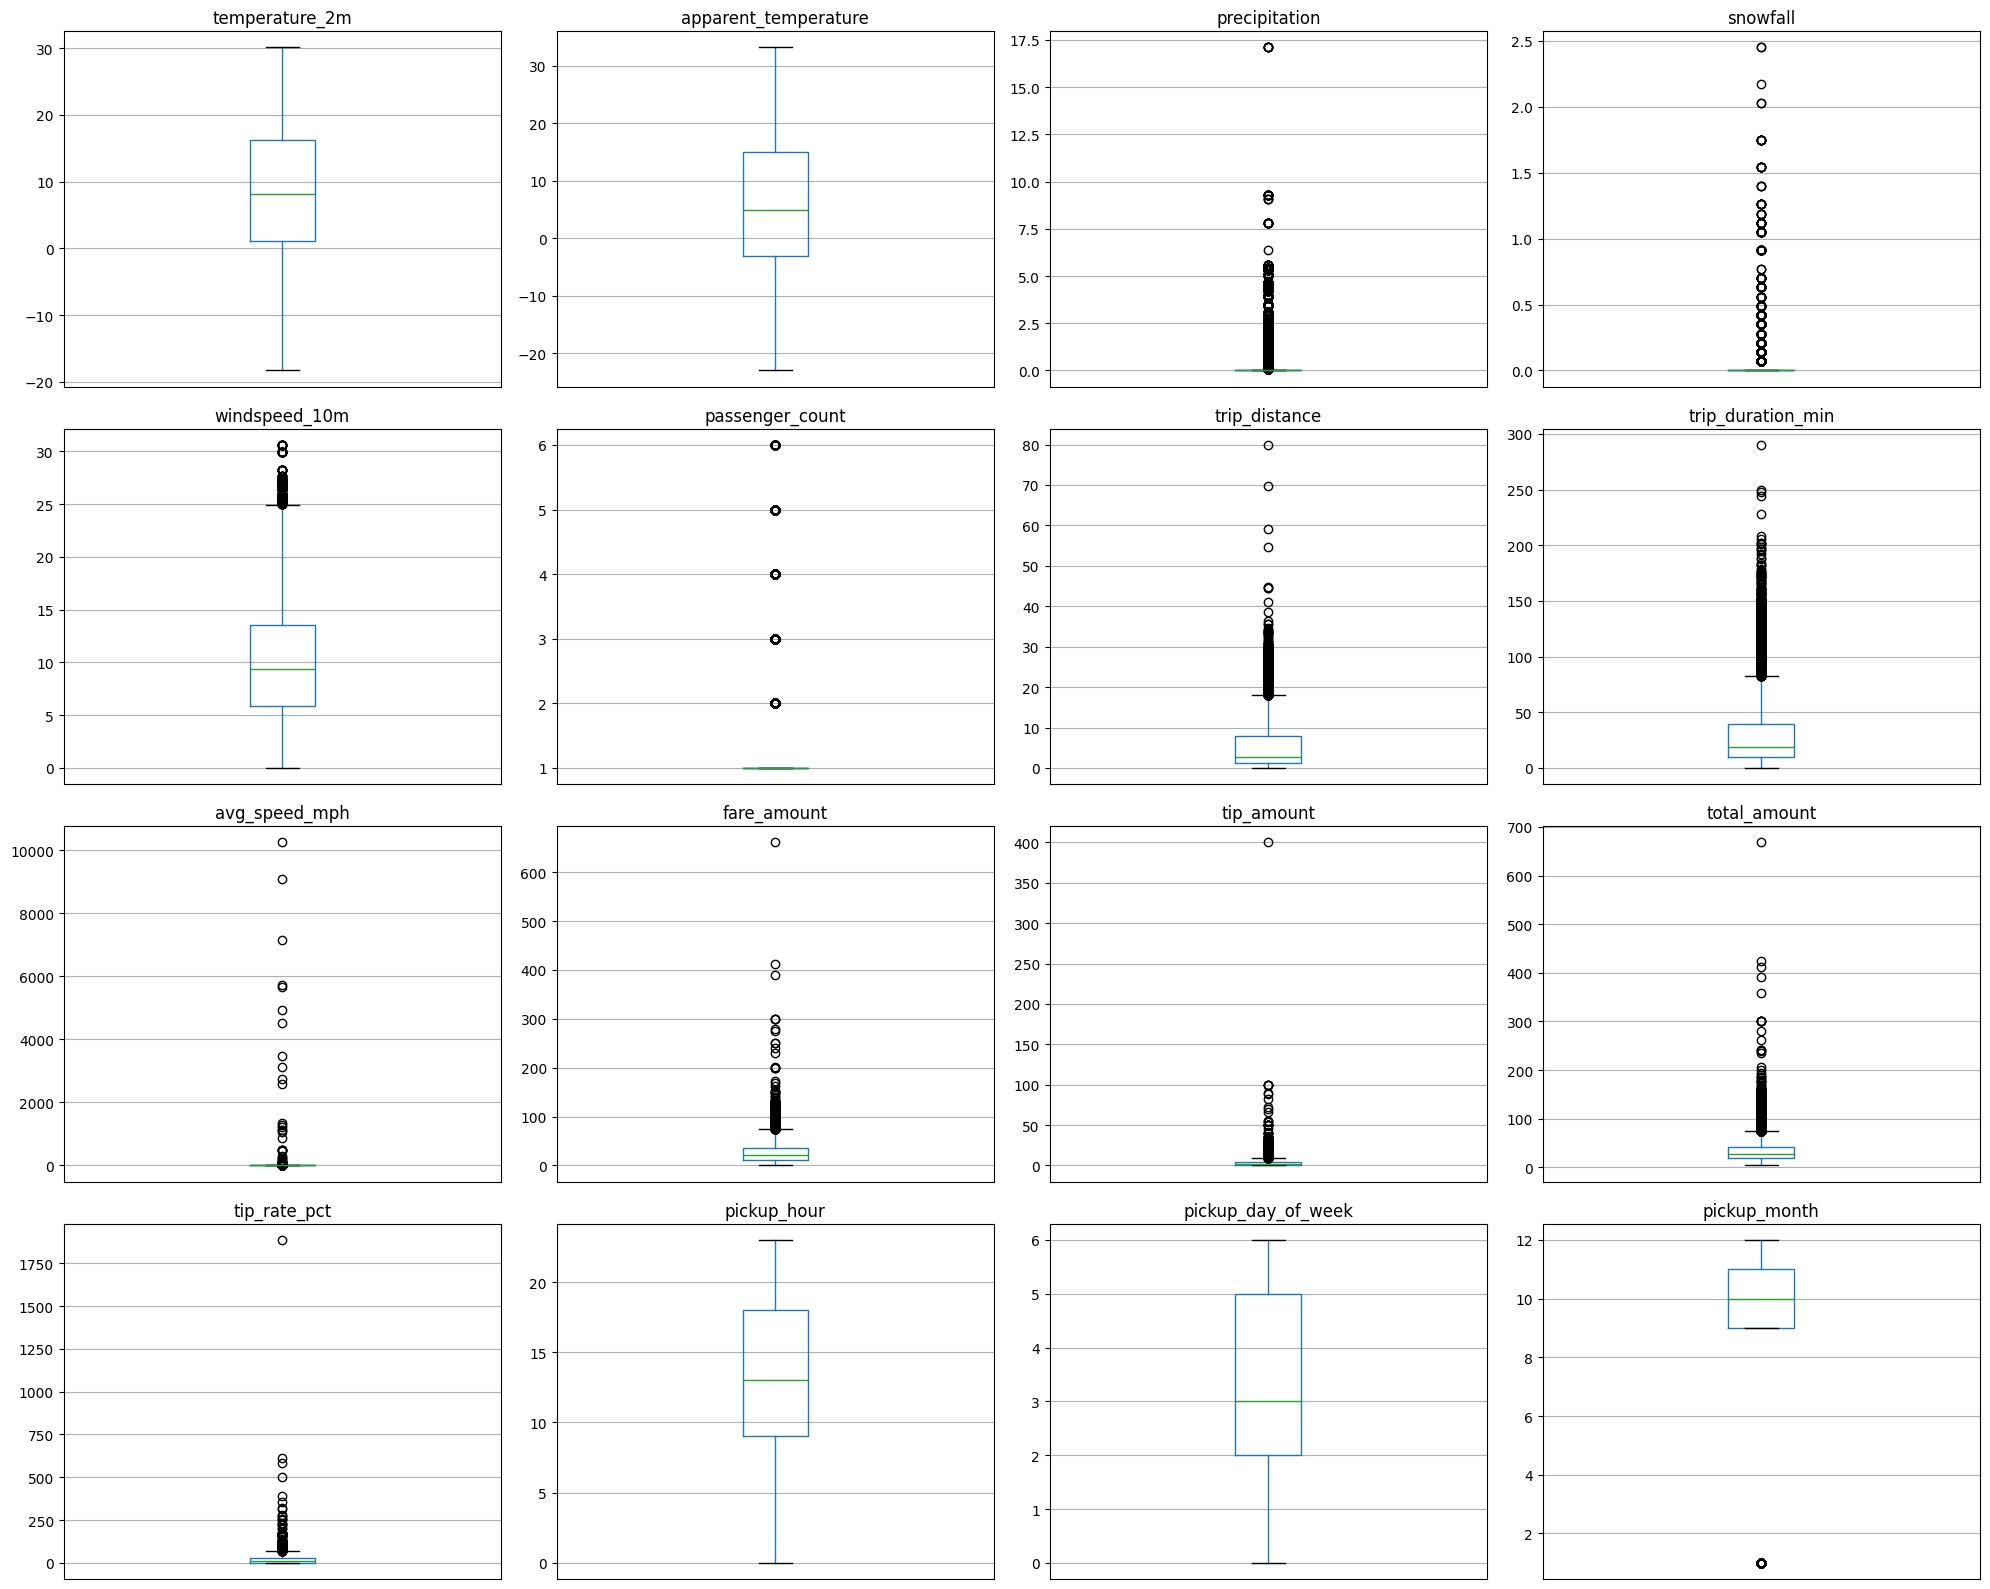

In [ ]:
import matplotlib.pyplot as plt

sample_small = sample_trip.sample(n=50000, seed=42).to_pandas()

n_cols = 4
n_rows = (len(num_features) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(num_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sample_small.boxplot(column=col)
    plt.title(col)
    plt.xticks([])

plt.tight_layout()
plt.show()

In [25]:
clip_features = [
    "temperature_2m",
    "apparent_temperature",
    "precipitation",
    "snowfall",
    "windspeed_10m",

    "trip_distance",
    "trip_duration_min",
    "avg_speed_mph",

    "fare_amount",
    "tip_amount",
    "total_amount",
    "tip_rate_pct"
]

no_clip_features = [
    "pickup_hour",
    "pickup_day_of_week",
    "pickup_month",
    "passenger_count"
]

In [33]:
# Contoh threshold yang lebih masuk akal
custom_bounds = {
    'trip_distance': (0, 80),  # miles - NYC ke mana pun jarang > 50
    'trip_duration_min': (0, 250),  # 3 jam max untuk NYC
    'avg_speed_mph': (0, 80),  # NYC traffic, > 60 mph tidak realistis
    'fare_amount': (0, 300),  # Fare normal NYC
    'tip_amount': (0, 200),  # Tips bisa tinggi tapi > $100 sangat jarang
    "tip_rate_pct": (0,600)
}

In [53]:
sample_trip_clean = sample_trip.sample(n=50_000, seed=42)

In [54]:
sample_trip_clean = sample_trip_clean

for col, (low, high) in custom_bounds.items():
    sample_trip_clean = sample_trip_clean.filter(
        (pl.col(col) >= low) & (pl.col(col) <= high)
    )

In [ ]:
# sample_trip_clean = sample_trip

# for col, (low, high) in custom_bounds.items():
#     sample_trip_clean = sample_trip_clean.filter(
#         (pl.col(col) >= low) & (pl.col(col) <= high)
#     )

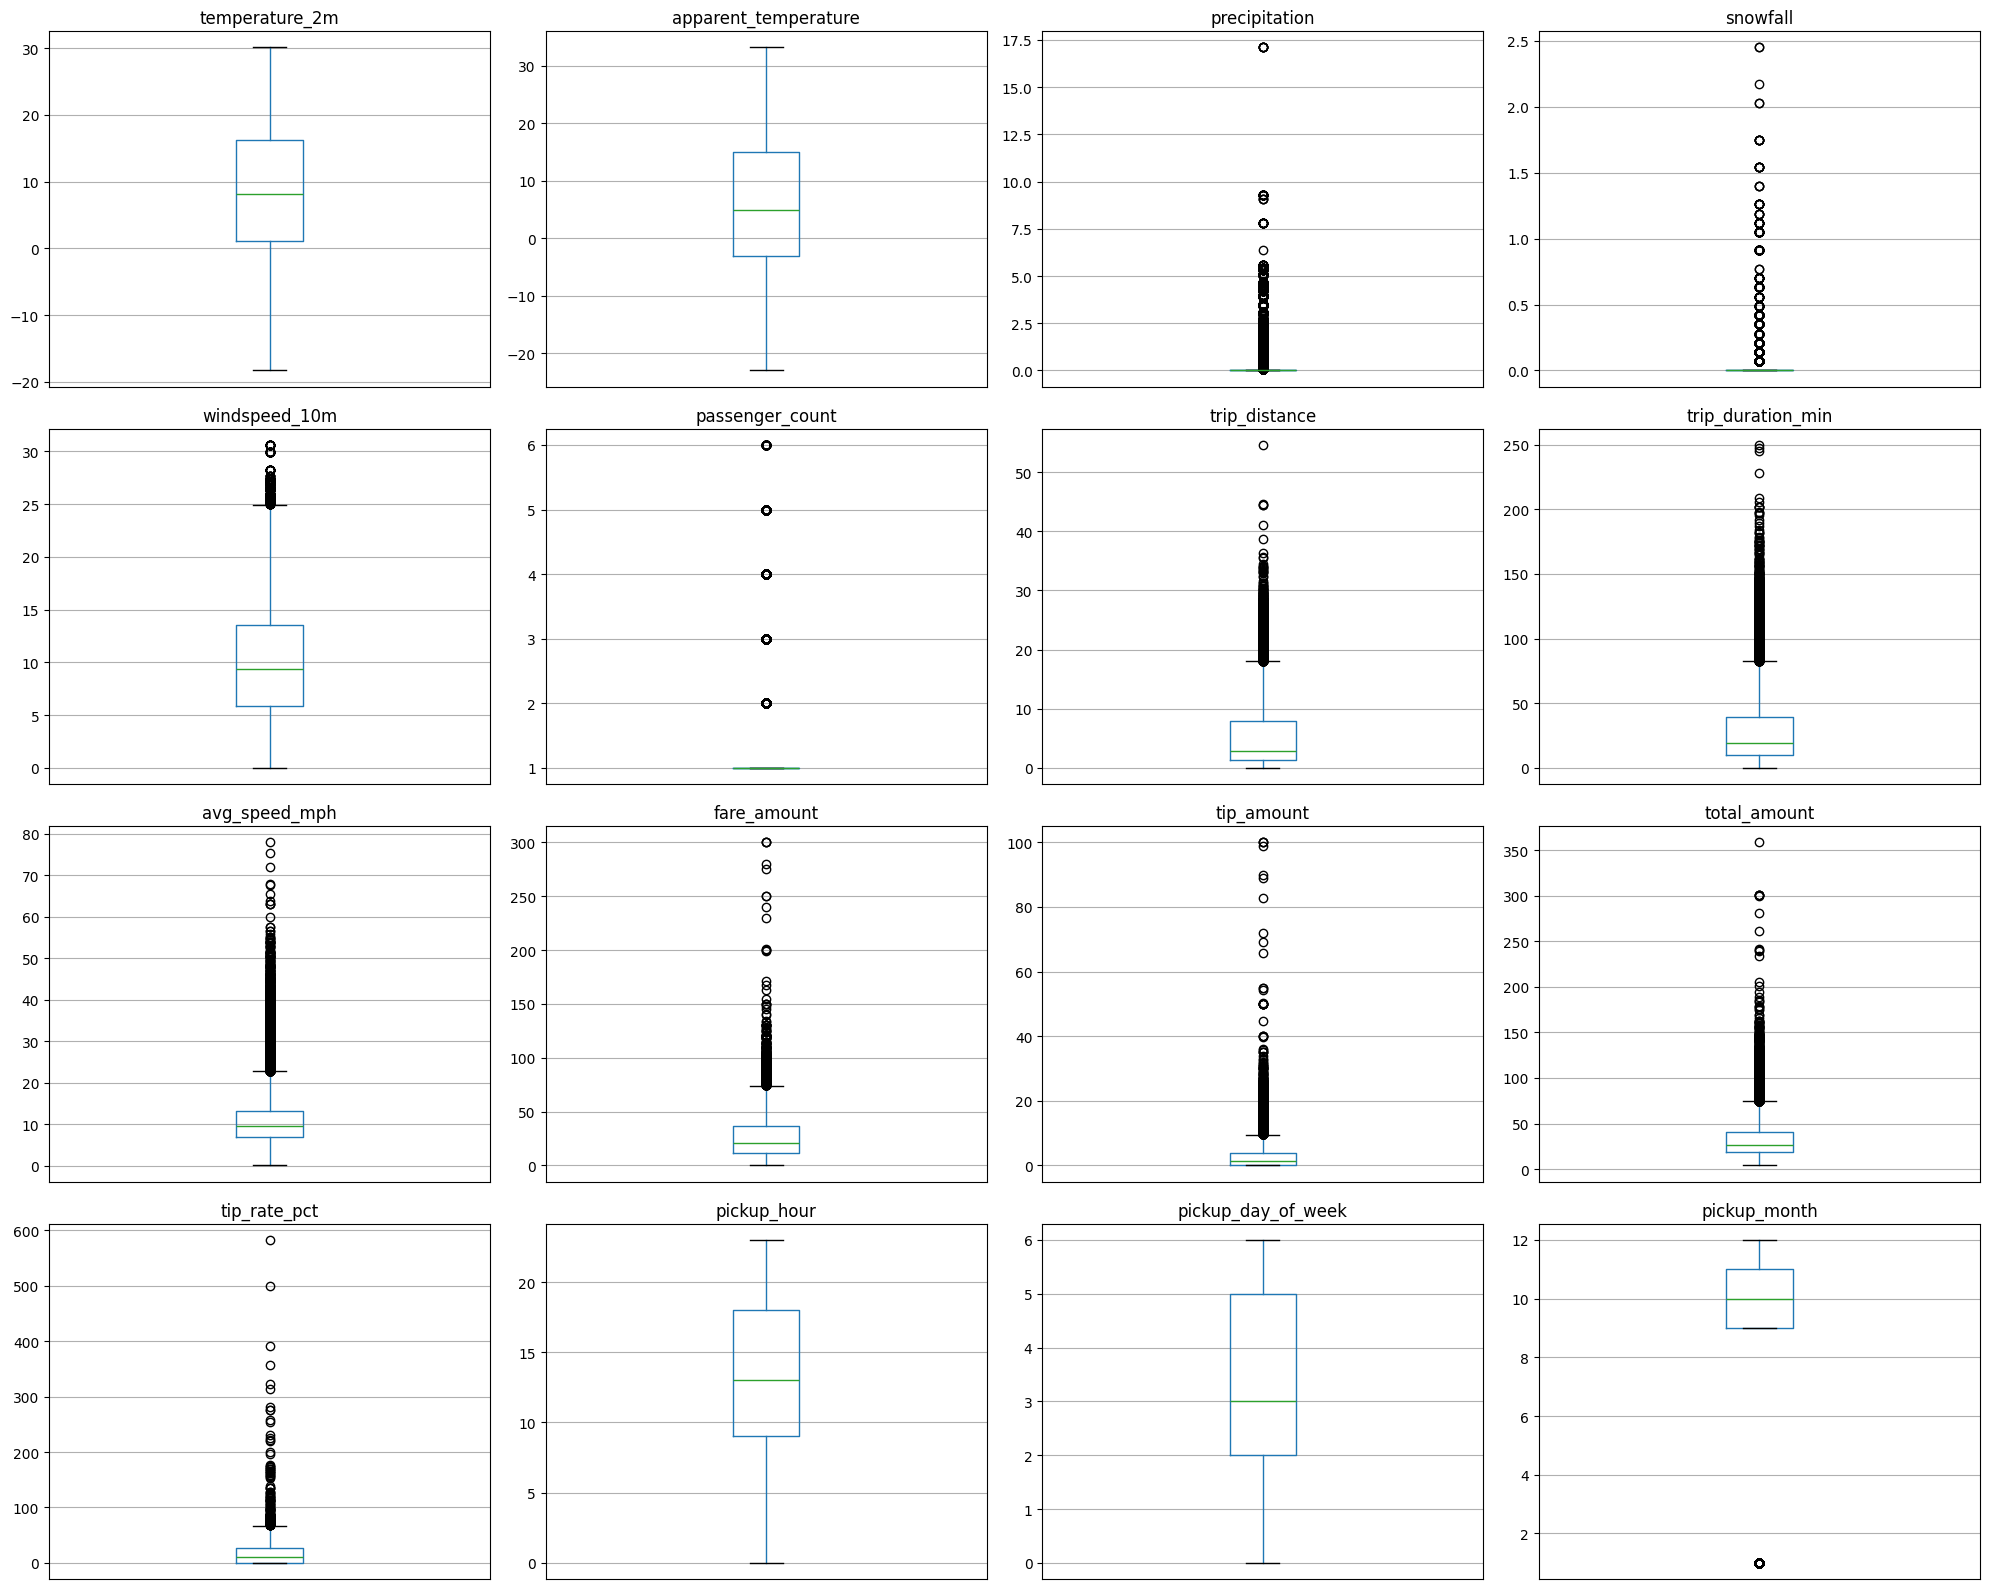

In [59]:
import matplotlib.pyplot as plt

# sample_small = sample_trip_clean.sample(n=50000, seed=42).to_pandas()
sample_small = sample_trip_clean.to_pandas()

n_cols = 4
n_rows = (len(num_features) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(num_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sample_small.boxplot(column=col)
    plt.title(col)
    plt.xticks([])

plt.tight_layout()
plt.show()

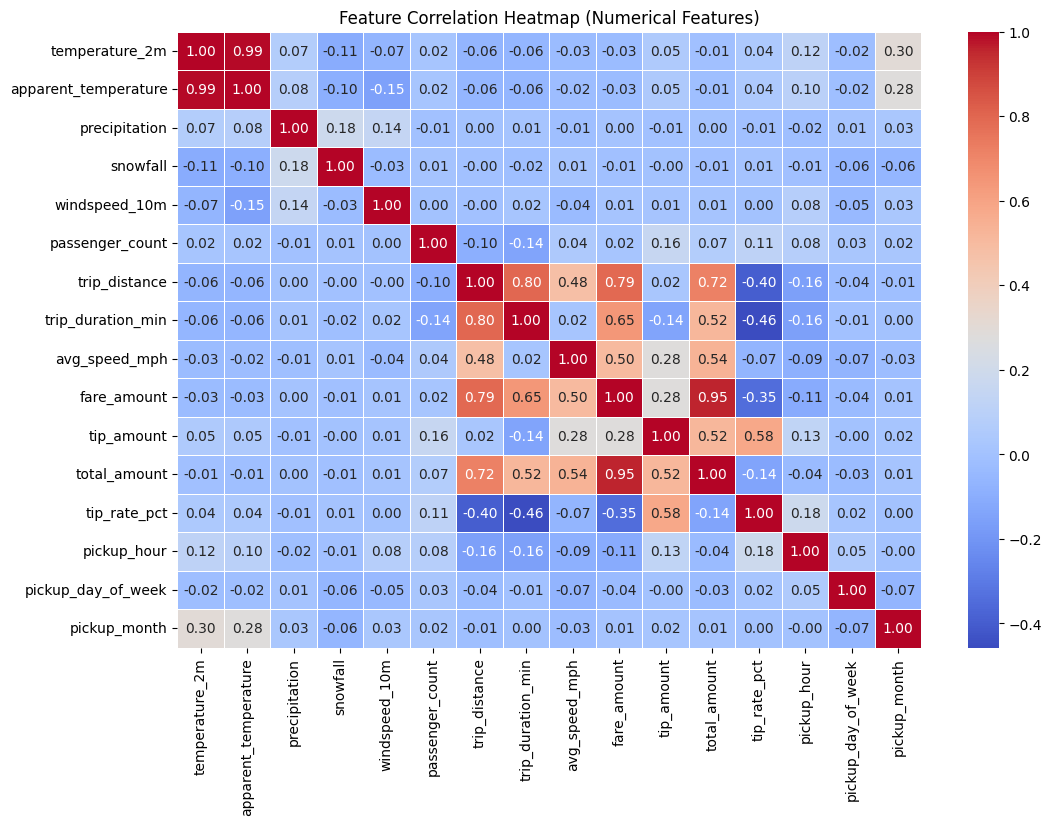

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

num_df = sample_trip_clean.select(num_features).to_pandas()
corr = num_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap (Numerical Features)")
plt.show()

In [61]:
import numpy as np
import pandas as pd

threshold = 0.50

corr_matrix = corr.abs()

high_corr_pairs = []

for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j and corr_matrix.loc[i, j] > threshold:
            high_corr_pairs.append(
                (i, j, corr_matrix.loc[i, j])
            )

corr_df = pd.DataFrame(high_corr_pairs, columns=[
    "Feature 1", "Feature 2", "Correlation"
])

# remove duplicates (A-B vs B-A)
corr_df["sorted_pair"] = corr_df.apply(
    lambda x: tuple(sorted([x["Feature 1"], x["Feature 2"]])),
    axis=1
)

corr_df = corr_df.drop_duplicates("sorted_pair").drop(columns=["sorted_pair"])

corr_df = corr_df.sort_values("Correlation", ascending=False)

print(corr_df)

            Feature 1             Feature 2  Correlation
0      temperature_2m  apparent_temperature     0.993313
13        fare_amount          total_amount     0.954925
2       trip_distance     trip_duration_min     0.798849
3       trip_distance           fare_amount     0.794267
4       trip_distance          total_amount     0.716051
6   trip_duration_min           fare_amount     0.646626
15         tip_amount          tip_rate_pct     0.583432
9       avg_speed_mph          total_amount     0.535078
7   trip_duration_min          total_amount     0.520642
14         tip_amount          total_amount     0.517470
8       avg_speed_mph           fare_amount     0.500291


In [ ]:
# final_features = [
#     "temperature_2m",
#     "precipitation",
#     "snowfall",
#     "windspeed_10m",

#     "passenger_count",
#     "trip_distance",
#     "avg_speed_mph",

#     "total_amount",
#     "tip_rate_pct",

#     "pickup_hour",
#     "pickup_day_of_week",
#     "pickup_month"
# ]

In [73]:
final_features = [
    # weather
    "temperature_2m",
    "precipitation",
    "snowfall",
    "windspeed_10m",

    # trip core
    "trip_distance",

    # behavior
    "passenger_count",
    "tip_rate_pct",

    # time
    "pickup_hour",
    "pickup_day_of_week",
    "pickup_month"
]

In [74]:
corr_df = sample_trip_clean.select(final_features).to_pandas().corr()

print(corr_df.round(3))

                    temperature_2m  precipitation  snowfall  windspeed_10m  \
temperature_2m               1.000          0.069    -0.106         -0.065   
precipitation                0.069          1.000     0.181          0.143   
snowfall                    -0.106          0.181     1.000         -0.033   
windspeed_10m               -0.065          0.143    -0.033          1.000   
trip_distance               -0.065          0.004    -0.004         -0.005   
passenger_count              0.018         -0.005     0.007          0.000   
tip_rate_pct                 0.043         -0.011     0.006          0.003   
pickup_hour                  0.117         -0.016    -0.013          0.081   
pickup_day_of_week          -0.021          0.009    -0.062         -0.046   
pickup_month                 0.298          0.028    -0.064          0.027   

                    trip_distance  passenger_count  tip_rate_pct  pickup_hour  \
temperature_2m             -0.065            0.018         0

In [75]:
corr_pairs = (
    corr_df
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

# remove self-correlation
corr_pairs = corr_pairs[corr_pairs["Feature 1"] != corr_pairs["Feature 2"]]

# sort strongest relationships
corr_pairs = corr_pairs.sort_values("Correlation", ascending=False)

print(corr_pairs.head(20))

             Feature 1           Feature 2  Correlation
9       temperature_2m        pickup_month     0.297931
90        pickup_month      temperature_2m     0.297931
67        tip_rate_pct         pickup_hour     0.181392
76         pickup_hour        tip_rate_pct     0.181392
21            snowfall       precipitation     0.180840
12       precipitation            snowfall     0.180840
31       windspeed_10m       precipitation     0.143227
13       precipitation       windspeed_10m     0.143227
7       temperature_2m         pickup_hour     0.116711
70         pickup_hour      temperature_2m     0.116711
56     passenger_count        tip_rate_pct     0.111981
65        tip_rate_pct     passenger_count     0.111981
37       windspeed_10m         pickup_hour     0.081230
73         pickup_hour       windspeed_10m     0.081230
75         pickup_hour     passenger_count     0.079250
57     passenger_count         pickup_hour     0.079250
1       temperature_2m       precipitation     0

In [70]:
sample_trip_clean.select(final_features).to_pandas().hist(figsize=(12,8))

array([[<Axes: title={'center': 'temperature_2m'}>,
        <Axes: title={'center': 'precipitation'}>,
        <Axes: title={'center': 'snowfall'}>],
       [<Axes: title={'center': 'windspeed_10m'}>,
        <Axes: title={'center': 'passenger_count'}>,
        <Axes: title={'center': 'trip_distance'}>],
       [<Axes: title={'center': 'avg_speed_mph'}>,
        <Axes: title={'center': 'total_amount'}>,
        <Axes: title={'center': 'tip_rate_pct'}>],
       [<Axes: title={'center': 'pickup_hour'}>,
        <Axes: title={'center': 'pickup_day_of_week'}>,
        <Axes: title={'center': 'pickup_month'}>]], dtype=object)

scaling

In [76]:
sample_trip_clean.shape

(49958, 32)

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [78]:
from sklearn.preprocessing import StandardScaler

X = sample_trip_clean.select(final_features).to_pandas()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [83]:
sample_trip_clean['pickup_zone'].value_counts()

pickup_zone,count
str,u32
"""Roosevelt Island""",129
"""Prospect-Lefferts Gardens""",143
"""Springfield Gardens South""",143
"""Morningside Heights""",168
"""Erasmus""",142
…,…
"""Saint Albans""",143
"""Middle Village""",103
"""Hunts Point""",113


In [79]:
k_values = [2, 3, 4, 5, 6, 7, 8]

In [82]:
sil_no_pca = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    sil_no_pca.append(score)

    print(f"[NO PCA] k={k} | silhouette={score:.4f}")

[NO PCA] k=2 | silhouette=0.2241
[NO PCA] k=3 | silhouette=0.1530
[NO PCA] k=4 | silhouette=0.1656


KeyboardInterrupt: 

pca

In [80]:
pca = PCA(n_components=0.85)
X_pca = pca.fit_transform(X_scaled)

print("PCA components:", pca.n_components_)

PCA components: 8


In [85]:
from sklearn.metrics import calinski_harabasz_score

ch_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)

    score = calinski_harabasz_score(X_pca, labels)
    ch_scores.append(score)

    print(f"[PCA] k={k} | CH score={score:.2f}")

[PCA] k=2 | CH score=7763.16
[PCA] k=3 | CH score=7517.36
[PCA] k=4 | CH score=7710.69
[PCA] k=5 | CH score=7184.82
[PCA] k=6 | CH score=7565.32
[PCA] k=7 | CH score=7878.49
[PCA] k=8 | CH score=7905.68


In [81]:
sil_pca = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)
    sil_pca.append(score)

    print(f"[PCA] k={k} | silhouette={score:.4f}")

[PCA] k=2 | silhouette=0.2490
[PCA] k=3 | silhouette=0.1758
[PCA] k=4 | silhouette=0.1826
[PCA] k=5 | silhouette=0.1718
[PCA] k=6 | silhouette=0.1933
[PCA] k=7 | silhouette=0.1823
[PCA] k=8 | silhouette=0.1867


In [84]:
from sklearn.metrics import davies_bouldin_score

db_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)

    score = davies_bouldin_score(X_pca, labels)
    db_scores.append(score)

    print(f"[PCA] k={k} | DB score={score:.4f}")

[PCA] k=2 | DB score=1.7204
[PCA] k=3 | DB score=1.9230
[PCA] k=4 | DB score=1.6756
[PCA] k=5 | DB score=1.6318
[PCA] k=6 | DB score=1.4286
[PCA] k=7 | DB score=1.3553
[PCA] k=8 | DB score=1.2823


In [86]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

gmm_scores = []

for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)
    gmm_scores.append(score)

    print(f"[GMM] k={k} | silhouette={score:.4f}")

[GMM] k=2 | silhouette=0.2256
[GMM] k=3 | silhouette=0.1791
[GMM] k=4 | silhouette=0.1507
[GMM] k=5 | silhouette=0.1882
[GMM] k=6 | silhouette=0.1299
[GMM] k=7 | silhouette=0.1167
[GMM] k=8 | silhouette=0.1203


In [44]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=20
)

labels = clusterer.fit_predict(X_pca)
from hdbscan.validity import validity_index

dbcv = validity_index(X_pca, labels)
print("DBCV score:", dbcv)

In [ ]:
import numpy as np

noise_ratio = np.mean(labels == -1)
print("Noise ratio:", noise_ratio)

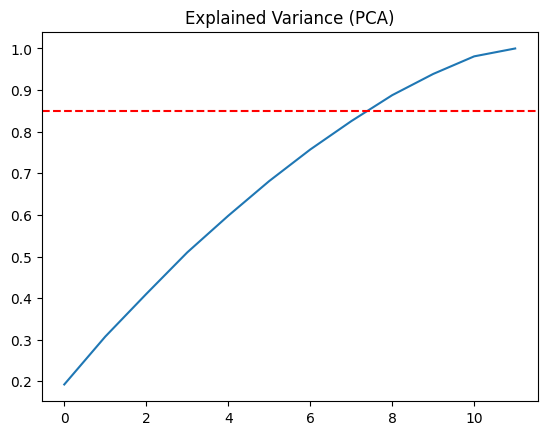

In [47]:
import numpy as np

explained = np.cumsum(pca.explained_variance_ratio_)

import matplotlib.pyplot as plt

plt.plot(explained)
plt.axhline(0.85, color='red', linestyle='--')
plt.title("Explained Variance (PCA)")
plt.show()

In [ ]:
n_components = np.argmax(explained >= 0.85) + 1

print("Selected components:", n_components)

In [ ]:
pca_final = PCA(n_components=n_components)

X_final = pca_final.fit_transform(X_scaled)